In [2]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"

In [1]:
import netket as nk
import numpy as np
import netket as nk
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import nnx
from flax import linen as nn
from netket.operator import AbstractOperator
from netket.experimental.observable import Renyi2EntanglementEntropy
from tqdm import tqdm
from scipy.optimize import minimize

C:\Users\iclis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Definimos el espacio en el que vamos a trabajar
from netket.hilbert import Spin, DiscreteHilbert, TensorHilbert
N = 2
N_ancilla = 2

hi_system = nk.hilbert.Spin(s=1/2, N=N)
hi_ancilla = nk.hilbert.Spin(s=1/2, N=N_ancilla)
hi_extended = nk.hilbert.Spin(s=1/2, N=N+N_ancilla)

$\mathcal{H_0}=Γ \sum_{i}\sigma_i^{(x)}+V\sum_{i}\sigma_i^{(z)}\sigma_{i+1}^{z} \qquad \mathcal{H_R}=\mathbb{I}_R$

$\mathcal{H}=\mathcal{H_0}\otimes\mathbb{I}_R$

In [4]:
# Importamos las matrices de Pauli y definimos el Hamiltoniano  H = H_0 ⊗ I_R
from netket.operator.spin import sigmax, sigmaz
Gamma = -1.5  #-1
V = -1
H_system=0
H_extended = 0

for i in range(N):
    H_system += Gamma * sigmax(hi_system, i)
    H_system += V * sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N)

for i in range(N):
    H_extended += Gamma * sigmax(hi_extended, i)
    H_extended += V * sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N)

In [5]:
#Model con simetría Z2
class RBM_Z2(nn.Module):

    alpha: int = 1
    trivial_Z2: bool = False  # True → simetría (ψ(x)=ψ(-x)), False → antisimetría (ψ(x)=-ψ(-x))

    @nn.compact
    def __call__(self, x):
        # Definimos la RBM
        worker = nk.models.RBM(alpha=self.alpha, param_dtype=float)

        # Calculamos la log-amplitud para x y -x
        output_x = jnp.atleast_1d(worker(x))
        output_inv_x = jnp.atleast_1d(worker(-x))

        # Apilamos las dos
        z2_stack = jnp.stack([output_x, output_inv_x], axis=0)

        # Combinamos según el tipo de simetría
        if self.trivial_Z2:
            # Invariante (simétrica)
            res = jax.nn.logsumexp(z2_stack, axis=0)
        else:
            # Antisimétrica (cambia de signo)
            b = jnp.array([1.0, -1.0])[:, None]   #b es el coeficiente que precede a la exponencial. Por defecto = 1.0
            res = jax.nn.logsumexp(z2_stack, b=b, axis=0)

        return res

In [6]:
model = RBM_Z2(alpha=1, trivial_Z2=True)
# model = nk.models.RBM(alpha=1)
vstate = nk.vqs.FullSumState(hilbert=hi_extended, model=model)

def compute_complete_density_matrix(vstate):
    """
    Calcula |psi><psi|
    """
    psi_vector = vstate.to_array()
    density_matrix = np.outer(psi_vector, np.conj(psi_vector))
    return density_matrix

def partial_trace1(rho, dims, traced_out):
    """
    rho: matriz densidad (np.array)
    dims: lista con dimensiones de cada subsistema (por ejemplo [2,2,2,2])
    traced_out: lista con los índices (0-based) de los subsistemas a trazar
    """
    import numpy as np

    # Número total de subsistemas
    N = len(dims)
    kept = [i for i in range(N) if i not in traced_out]

    # Reordenamos los índices: primero los subsistemas que conservamos
    reshaped = rho.reshape(dims + dims)
    perm = kept + traced_out + [i + N for i in kept + traced_out]
    reshaped = np.transpose(reshaped, perm)

    # Tamaños
    dimA = int(np.prod([dims[i] for i in kept]))
    dimB = int(np.prod([dims[i] for i in traced_out]))

    # Ahora la traza parcial
    reshaped = reshaped.reshape(dimA, dimB, dimA, dimB)
    rho_reduced = np.einsum("ijik->jk", reshaped)
    return rho_reduced

def partial_trace(rho, keep_indices, subsystem_dims):
    """
    Calcula la traza parcial de un operador densidad
    
    Args:
        rho: Operador densidad completo (2^N x 2^N)
        keep_indices: Lista de índices de los subsistemas a mantener
        subsystem_dims: Lista de dimensiones de cada subsistema
    
    Returns:
        rho_reduced: Operador densidad reducido
    """
    # Verificar dimensiones
    total_dim = np.prod(subsystem_dims)
    if rho.shape != (total_dim, total_dim):
        raise ValueError(f"Dimensiones incompatibles: rho {rho.shape}, subsistemas {total_dim}")
    
    N = len(subsystem_dims)  # Número total de subsistemas
    trace_indices = [i for i in range(N) if i not in keep_indices]
    
    # Reordenar índices: primero los que se mantienen, luego los que se trazan
    new_order = keep_indices + trace_indices
    dims_ordered = [subsystem_dims[i] for i in new_order]
    
    # Reordenar la matriz densidad
    rho_reshaped = rho.reshape(subsystem_dims * 2)
    rho_reordered = np.transpose(rho_reshaped, new_order + [N + i for i in new_order])
    
    # Nuevas dimensiones después de reordenar
    dim_keep = np.prod([subsystem_dims[i] for i in keep_indices])
    dim_trace = np.prod([subsystem_dims[i] for i in trace_indices])
    
    # Reshape para trazar
    rho_reordered = rho_reordered.reshape(dim_keep, dim_trace, dim_keep, dim_trace)
    
    # Hacer la traza parcial sobre los últimos subsistemas
    rho_reduced = np.trace(rho_reordered, axis1=1, axis2=3)
    
    return rho_reduced

def partial_trace_spins(rho, keep_spins, total_spins):
    """
    Traza parcial específica para spins 1/2
    
    Args:
        rho: Operador densidad completo (2^N x 2^N)
        keep_spins: Lista de índices de spins a mantener (ej: [0, 2])
        total_spins: Número total de spins
    
    Returns:
        rho_reduced: Operador densidad reducido para los spins especificados
    """
    subsystem_dims = [2] * total_spins  # Cada spin tiene dimensión 2
    return partial_trace(rho, keep_spins, subsystem_dims)

def entanglement_entropy(rho_reduced):
    """
    Calcula la entropía de entrelazamiento S = -ln(Tr(rho^2))
    para una matriz densidad reducida rho_reduced.
    """
    # Aseguramos hermiticidad numérica
    # rho_reduced = 0.5 * (rho_reduced + rho_reduced.conj().T)

    # Calcula rho^2
    rho2 = rho_reduced @ rho_reduced

    # Calcula Tr(rho^2)
    purity = np.real(np.trace(rho2))

    # Evita log(0)
    purity = max(purity, 1e-15)

    # Entropía de entrelazamiento
    S = -np.log(purity)
    return S



In [7]:
rho = compute_complete_density_matrix(vstate)
rho_reduced1 = partial_trace1(rho, dims=[2]*(N+N_ancilla), traced_out=list(range(N, N+N_ancilla)))
print("Matriz densidad reducida (trazando ancilla):")
print(rho_reduced1)
rho_reduced = partial_trace_spins(rho, keep_spins=list(range(N)), total_spins=N+N_ancilla)
print("Matriz densidad reducida (trazando ancilla) usando partial_trace_spins:")
print(rho_reduced)
state_vector = vstate.to_array()


Matriz densidad reducida (trazando ancilla):
[[0.2497762  0.24999962 0.24999961 0.24977584]
 [0.24999962 0.2502238  0.25022302 0.24999961]
 [0.24999961 0.25022302 0.2502238  0.24999962]
 [0.24977584 0.24999961 0.24999962 0.2497762 ]]
Matriz densidad reducida (trazando ancilla) usando partial_trace_spins:
[[0.25017574 0.24999956 0.24999975 0.25017528]
 [0.24999956 0.24982426 0.24982358 0.24999975]
 [0.24999975 0.24982358 0.24982426 0.24999956]
 [0.25017528 0.24999975 0.24999956 0.25017574]]


In [15]:
def flatten_parameters(params):
    """Convierte parámetros de NetKet a array 1D para scipy"""
    flat, tree_def = jax.tree_util.tree_flatten(params)
    shapes = [p.shape for p in flat]
    sizes = [p.size for p in flat]
    flat_array = np.concatenate([p.reshape(-1) for p in flat])
    return flat_array, tree_def, shapes

def unflatten_parameters(flat_array, tree_def, shapes):
    """Convierte array 1D de vuelta a parámetros de NetKet"""
    params = []
    start = 0
    for shape in shapes:
        size = np.prod(shape)
        params.append(flat_array[start:start+size].reshape(shape))
        start += size
    return jax.tree_util.tree_unflatten(tree_def, params)

def minimize_free_energy(vstate, H, T, keep_indices, method='BFGS'):
    """
    Minimiza F = <H> - T S₂ usando scipy.optimize
    
    Args:
        vstate: FullSumState de NetKet
        H: Hamiltoniano
        T: Temperatura
        keep_indices: índices de los spins a mantener
        method: método de optimización ('BFGS', 'L-BFGS-B', 'Nelder-Mead')
    """
    total_spins = vstate.hilbert.size
    
    # Aplanar parámetros iniciales
    flat_params, tree_def, shapes = flatten_parameters(vstate.parameters)

    results = {}
    
    def loss(params_flat):
        # Reconstruir parámetros
        vstate.parameters = unflatten_parameters(params_flat, tree_def, shapes)
        
        # Calcular F = <H> - T S₂
        psi = vstate.to_array()
        rho = np.outer(psi, np.conj(psi))
        rho_A = partial_trace_spins(rho, keep_indices, total_spins)
        S2 = entanglement_entropy(rho_A)
        E = vstate.expect(H).mean.real
        
        F_val =   - T * S2
        results['E'] = E
        results['S2'] = S2
        return F_val
    
    # Optimizar con scipy
    result = minimize(loss, flat_params, method=method, options={'disp': False})
    
    # Poner parámetros óptimos de vuelta
    vstate.parameters = unflatten_parameters(result.x, tree_def, shapes)
    result.E_best = results['E']
    result.S2_best = results['S2']
    
    return result

# Inicializar parámetros 
vstate.init_parameters()

# Minimizar F para temperatura T=1.0, manteniendo spins [0,1]
result = minimize_free_energy(
    vstate=vstate,
    H=H_extended, 
    T=1,    
    keep_indices=list(range(N)),  # Traza parcial sobre la ancilla
    method='BFGS'
)

print(f"F mínimo: {result.fun:.8f}")
print(f"Energía E correspondiente: {result.E_best:.6f}")
print(f"Entropía S₂ correspondiente: {result.S2_best:.6f}")
print(f"¿Éxito?: {result.success}")


F mínimo: -1.38629435
Energía E correspondiente: -0.000183
Entropía S₂ correspondiente: 1.386294
¿Éxito?: True


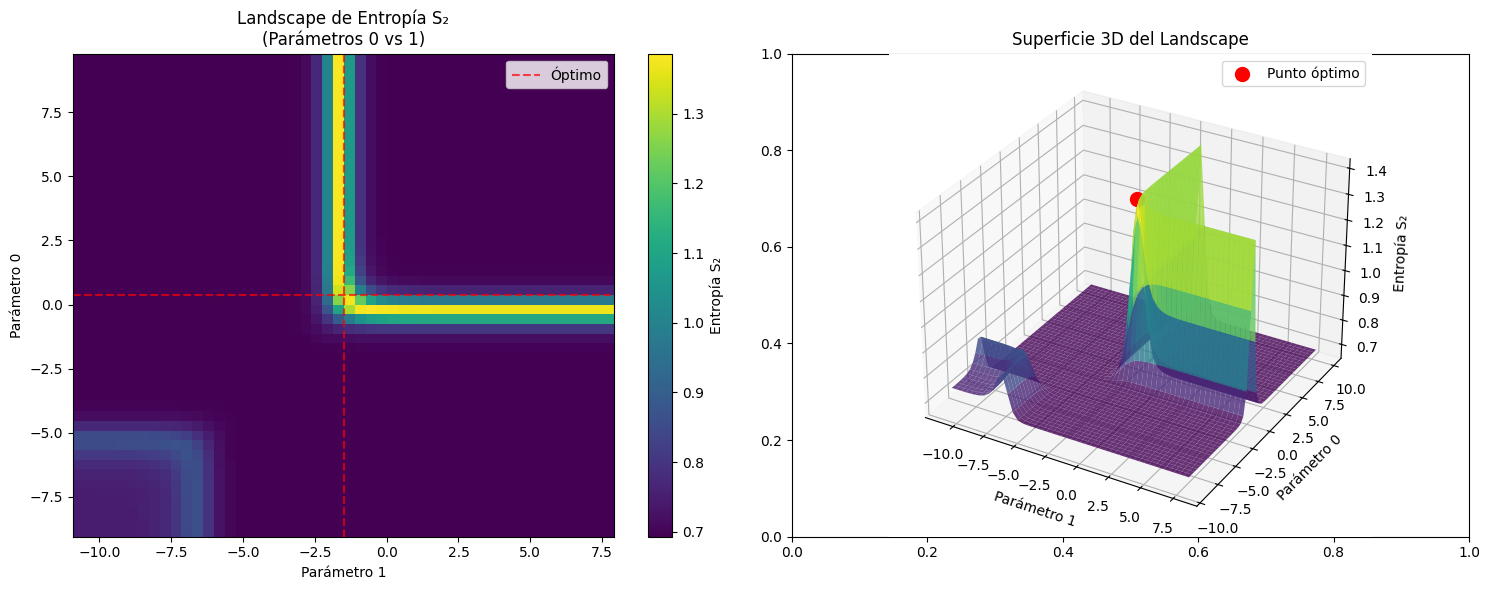

In [21]:
def plot_entropy_landscape_2D(vstate, param_indices, grid_size=50, fixed_params=None):
    """
    Visualiza el landscape de entropía en 2D variando dos parámetros.
    
    Args:
        vstate: FullSumState con parámetros óptimos
        param_indices: tupla (idx1, idx2) - índices en el array plano
        grid_size: número de puntos por dimensión
        fixed_params: valores fijos para otros parámetros (default: óptimos)
    """
    # Obtener parámetros óptimos
    flat_opt, tree_def, shapes = flatten_parameters(vstate.parameters)
    flat_opt = flat_opt.copy()
    
    # Crear grid 2D
    idx1, idx2 = param_indices
    
    # Rango de variación (ajusta según necesites)
    range1 = np.linspace(flat_opt[idx1] - 3*np.pi, flat_opt[idx1] + 3*np.pi, grid_size)
    range2 = np.linspace(flat_opt[idx2] - 3*np.pi, flat_opt[idx2] + 3*np.pi, grid_size)
    
    # Matriz para almacenar entropías
    entropy_grid = np.zeros((grid_size, grid_size))
    
    # Calcular entropía en cada punto del grid
    for i, val1 in enumerate(range1):
        for j, val2 in enumerate(range2):
            # Crear copia de parámetros
            temp_params = flat_opt.copy()
            temp_params[idx1] = val1
            temp_params[idx2] = val2
            
            # Restaurar estado
            vstate.parameters = unflatten_parameters(temp_params, tree_def, shapes)
            
            # Calcular entropía
            psi = vstate.to_array()
            rho = np.outer(psi, np.conj(psi))
            rho_A = partial_trace_spins(rho, list(range(N)), 4)
            entropy_grid[i, j] = entanglement_entropy(rho_A)
    
    # Restaurar parámetros óptimos
    vstate.parameters = unflatten_parameters(flat_opt, tree_def, shapes)
    
    # Crear figura
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    
    # Subplot 1: Heatmap
    im = ax[0].imshow(entropy_grid, extent=[range2.min(), range2.max(), 
                                             range1.min(), range1.max()], 
                      origin='lower', aspect='auto', cmap='viridis')
    ax[0].set_xlabel(f'Parámetro {idx2}')
    ax[0].set_ylabel(f'Parámetro {idx1}')
    ax[0].set_title(f'Landscape de Entropía S₂\n(Parámetros {idx1} vs {idx2})')
    ax[0].axhline(flat_opt[idx1], color='r', linestyle='--', alpha=0.7, label='Óptimo')
    ax[0].axvline(flat_opt[idx2], color='r', linestyle='--', alpha=0.7)
    ax[0].legend()
    plt.colorbar(im, ax=ax[0], label='Entropía S₂')
    
    # Subplot 2: Contorno 3D
    X, Y = np.meshgrid(range2, range1)
    ax[1] = plt.subplot(122, projection='3d')
    surf = ax[1].plot_surface(X, Y, entropy_grid, cmap='viridis', 
                              alpha=0.8, linewidth=0, antialiased=True)
    ax[1].scatter(flat_opt[idx2], flat_opt[idx1], entropy_grid.max(), 
                  color='r', s=100, label='Punto óptimo')
    ax[1].set_xlabel(f'Parámetro {idx2}')
    ax[1].set_ylabel(f'Parámetro {idx1}')
    ax[1].set_zlabel('Entropía S₂')
    ax[1].set_title('Superficie 3D del Landscape')
    ax[1].legend()
    
    plt.tight_layout()
    return entropy_grid, fig

# Uso: visualizar dos parámetros específicos
# (elige índices basados en la dimensionalidad de tus parámetros)
entropy_data, fig = plot_entropy_landscape_2D(vstate, param_indices=(0,1), grid_size=50)
plt.show()

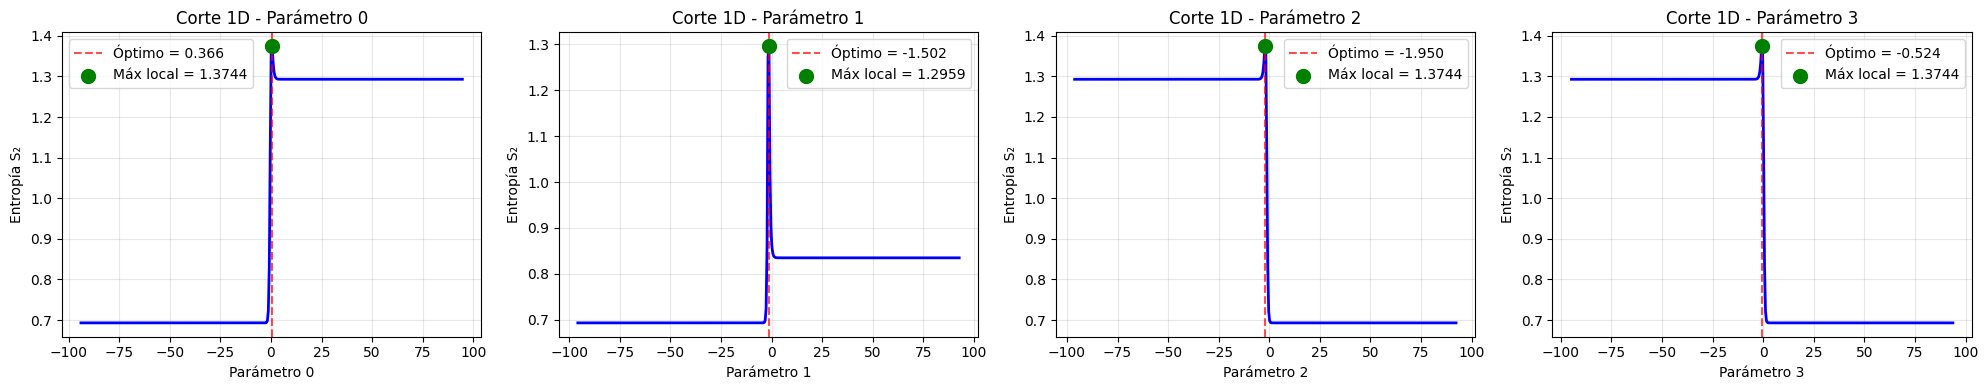

In [17]:
def plot_entropy_slices(vstate, param_indices=None, n_slices=4, points=100):
    """
    Visualiza cortes 1D de la entropía variando un parámetro a la vez.
    
    Args:
        vstate: FullSumState con parámetros óptimos
        param_indices: lista de índices a visualizar (None = primeros n_slices)
        n_slices: número de parámetros a visualizar
        points: puntos por slice
    """
    # Obtener parámetros óptimos
    flat_opt, tree_def, shapes = flatten_parameters(vstate.parameters)
    
    if param_indices is None:
        n_params = min(n_slices, len(flat_opt))
        param_indices = list(range(n_params))
    
    fig, axes = plt.subplots(1, len(param_indices), figsize=(5*len(param_indices), 4))
    if len(param_indices) == 1:
        axes = [axes]
    
    for idx, (param_idx, ax) in enumerate(zip(param_indices, axes)):
        # Rango de variación
        param_val = flat_opt[param_idx]
        param_range = np.linspace(param_val - 30*np.pi, param_val + 30*np.pi, points)
        
        entropies = []
        
        for val in param_range:
            # Modificar solo este parámetro
            temp_params = flat_opt.copy()
            temp_params[param_idx] = val
            
            # Calcular entropía
            vstate.parameters = unflatten_parameters(temp_params, tree_def, shapes)
            psi = vstate.to_array()
            rho = np.outer(psi, np.conj(psi))
            rho_A = partial_trace_spins(rho, list(range(N)), 4)
            entropies.append(entanglement_entropy(rho_A))
        
        # Restaurar parámetros óptimos
        vstate.parameters = unflatten_parameters(flat_opt, tree_def, shapes)
        
        # Graficar
        ax.plot(param_range, entropies, 'b-', linewidth=2)
        ax.axvline(param_val, color='r', linestyle='--', alpha=0.7, 
                   label=f'Óptimo = {param_val:.3f}')
        ax.set_xlabel(f'Parámetro {param_idx}')
        ax.set_ylabel('Entropía S₂')
        ax.set_title(f'Corte 1D - Parámetro {param_idx}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Marcar máximo en el corte
        max_idx = np.argmax(entropies)
        ax.scatter(param_range[max_idx], entropies[max_idx], color='g', s=100, 
                   zorder=5, label=f'Máx local = {entropies[max_idx]:.4f}')
        ax.legend()
    
    plt.tight_layout()
    return fig

# Uso: visualizar cortes 1D de los primeros 4 parámetros
fig = plot_entropy_slices(vstate, n_slices=4, points=400)
plt.show()

In [18]:
from flax import serialization
params = vstate.parameters
bytes_out = serialization.to_bytes(params)

with open("params_fullsum.msgpack", "wb") as f:
    f.write(bytes_out)

In [15]:
T = np.linspace(0,2,30)
H_history = []
S_history = []
F_history = []

for t in T:
    vstate.init_parameters()

    # Minimizar F para temperatura T=1.0, manteniendo spins [0,1]
    result = minimize_free_energy(
        vstate=vstate,
        H=H_extended, 
        T=t,    
        keep_indices=list(range(N)),  # Traza parcial sobre la ancilla
        method='BFGS', 
    )
    F_history.append(result.fun)
    H_history.append(result.E_best)
    S_history.append(result.S2_best)
    print(f"T = {t:.2f} ¿Éxito?: {result.success}")


T = 0.00 ¿Éxito?: True
T = 0.07 ¿Éxito?: True
T = 0.14 ¿Éxito?: True
T = 0.21 ¿Éxito?: True
T = 0.28 ¿Éxito?: True
T = 0.34 ¿Éxito?: True
T = 0.41 ¿Éxito?: True
T = 0.48 ¿Éxito?: True
T = 0.55 ¿Éxito?: True
T = 0.62 ¿Éxito?: True
T = 0.69 ¿Éxito?: True
T = 0.76 ¿Éxito?: True
T = 0.83 ¿Éxito?: True
T = 0.90 ¿Éxito?: True
T = 0.97 ¿Éxito?: True
T = 1.03 ¿Éxito?: True
T = 1.10 ¿Éxito?: True
T = 1.17 ¿Éxito?: True
T = 1.24 ¿Éxito?: True
T = 1.31 ¿Éxito?: True
T = 1.38 ¿Éxito?: True
T = 1.45 ¿Éxito?: True
T = 1.52 ¿Éxito?: True
T = 1.59 ¿Éxito?: True
T = 1.66 ¿Éxito?: True
T = 1.72 ¿Éxito?: True
T = 1.79 ¿Éxito?: True
T = 1.86 ¿Éxito?: True
T = 1.93 ¿Éxito?: True
T = 2.00 ¿Éxito?: True


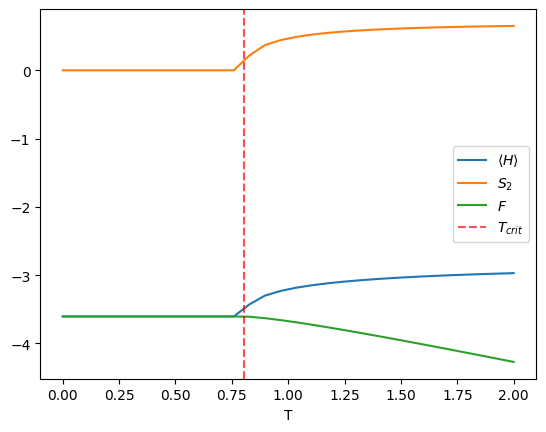

In [28]:
hamiltonian = np.array([
    [2*V, Gamma, Gamma, 0],
    [Gamma, -2*V, 0, Gamma],
    [Gamma, 0, -2*V, Gamma],
    [0, Gamma, Gamma, 2*V]
])

eig = np.linalg.eigvals(hamiltonian)
eig_2 = (np.sort(eig))[:2]
t_c = np.abs(eig_2[1]-eig_2[0])/2
plt.plot(T, H_history, label=r"$\langle H \rangle $")
plt.plot(T, S_history, label=r"$S_2$")
plt.plot(T, F_history, label=r"$F$")
plt.axvline(x=t_c, color='red', linestyle='--', alpha=0.7, label=r"$T_{crit}$")
plt.xlabel("T")
plt.legend()
plt.show()

In [15]:
print(F_history)
print(H_history)
print(S_history)

[-3.60555127531178, -3.605551275317158, -3.605551274512898, -3.605551275416086, -3.6055512738995645, -3.6055512753850336, -3.6055512753211403, -3.6055512747794354, -3.6055512706813033, -3.605551275070867, -3.605551270067524, -3.6055512725042966, -3.6092777154634077, -3.6303203523646257, -3.6584744063091224, -3.690676779835767, -3.7256133737263486, -3.7625429457519806, -3.8009939255281284, -3.8406438992005336, -3.881261472130581, -3.9226745584672025, -3.964751617241964, -4.007389850053537, -4.050507525562062, -4.094038527302896, -4.137928797689049, -4.182133509627089, -4.226615422218169, -4.271342776089965]
[-3.6055512753117727, -3.6055512753142893, -3.605551274475035, -3.605551275411756, -3.605551273739227, -3.6055512753766816, -3.6055512753025116, -3.605551274663859, -3.6055512698102925, -3.60555127498683, -3.605551268788476, -3.6055512715964104, -3.4292290161629526, -3.3001323804380434, -3.2318439346288663, -3.1847931152224933, -3.1491616700598866, -3.120726394461411, -3.097278552936

There is a transtition a certain temperature $T_{crit}$, where $S_2$ stops being 0 and $\langle H \rangle$ starts increasing. Therefore, we can say that the system stops being in the ground state for $T=0$, and more states appear in our wavefunction. To see where $T_{crit}$ takes place, we can use the following ansatz for our wavefunction:
 
$$
|\Psi\rangle = \sqrt{1-p} |\phi_0\rangle \otimes |a_0\rangle + \sqrt{p} |\phi_1\rangle \otimes |a_1\rangle
$$

It is a Schmidt decomsition, using only the two lowest energy eigenstates because, close to $T_{crit}$ the population starts to migrate from $|\phi_0\rangle$ to $|\phi_1\rangle$ as $T$ increases.

The energy is 
$$
\langle H \rangle = (1-p)E_0 + pE_1
$$
And the energy variation from the ground state:
$$
\Delta E = \langle H \rangle -E_0 = p(E_1-E_0)
$$

We have chosen $\langle a_0|a_1\rangle =0$, so the reduced demsity matrix is 
$$
\rho_S = Tr_A(|\Psi\rangle\langle\Psi |) = (1-p)|\phi_0\rangle\langle\phi_0 | + p|\phi_1\rangle\langle\phi_1 |
$$
And the second order Rényi entropy:
$$
S_2 = -\ln(Tr(\rho_S^2)) = -\ln((1-p)^2+p^2)
$$

The free energy $F(T,p)$ is therefore:
$$
F(T,p) = \langle H \rangle - TS_2 = (1-p)E_0 + pE_1  +T\ln((1-p)^2+p^2)
$$
And, expanding up to order $p$
$$
F(T,p)  = E_0 + p(E_1-E_0)-T(2p)+\mathcal{O}(p^2)\approx E_0 + p(E_1-E_0)-T(2p)
$$

The pure ground state ($p=0$) is stable if $\frac{\partial F}{\partial p}\big|_{p=0} > 0 $:
$$
E_1 - E_0 -2T > 0 \Rightarrow T<\frac{E_1-E_0}{2}
$$
The trasition happens at $T_{crit}=\frac{E_1-E_0}{2}$.

In [154]:

G = np.linspace(-2, -0.5, 20)
T = np.linspace(0,2,40)
T_crit_history = []
T_crit_approx = []

for g in G:
    Gamma = g  
    V = -1
    H_extended = 0
    # S_history = []
    for i in range(N):
        H_extended += Gamma * sigmax(hi_extended, i)
        H_extended += V * sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N)
    hamiltonian = np.array([
        [2*V, Gamma, Gamma, 0],
        [Gamma, -2*V, 0, Gamma],
        [Gamma, 0, -2*V, Gamma],
        [0, Gamma, Gamma, 2*V]
    ])
    eig = np.linalg.eigvals(hamiltonian)
    eig_2 = (np.sort(eig))[:2]
    t_c = np.abs(eig_2[1]-eig_2[0])/2
    T_crit_approx.append(t_c)

    for t in T:
        vstate.init_parameters()
        result = minimize_free_energy(
            vstate=vstate,
            H=H_extended, 
            T=t,    
            keep_indices=list(range(N)), 
            method='BFGS', 
        )
        # S_history.append(result.S2_best)
        if result.S2_best > 0.1:
            t_crit = t - (T[1]-T[0])
            break
    T_2 = np.linspace(t_crit, (t_crit+T[1]-T[0]), 15)
    # S_history = []
    for t in T_2:
        vstate.init_parameters()
        result = minimize_free_energy(
            vstate=vstate,
            H=H_extended, 
            T=t,    
            keep_indices=list(range(N)), 
            method='BFGS', 
        )
        # S_history.append(result.S2_best)
        if result.S2_best > 0.1:
            t_crit = t - (T_2[1]-T_2[0])
            break
    T_crit_history.append(t_crit)
    print(f"Gamma = {g:.2f}, T_crit =  {t_crit:.2f}, T_crit_approx = {t_c:.2f}")

Gamma = -2.00, T_crit =  1.24, T_crit_approx = 1.24
Gamma = -1.92, T_crit =  1.17, T_crit_approx = 1.17
Gamma = -1.84, T_crit =  1.10, T_crit_approx = 1.10
Gamma = -1.76, T_crit =  1.03, T_crit_approx = 1.03
Gamma = -1.68, T_crit =  0.96, T_crit_approx = 0.96
Gamma = -1.61, T_crit =  0.89, T_crit_approx = 0.89
Gamma = -1.53, T_crit =  0.83, T_crit_approx = 0.82
Gamma = -1.45, T_crit =  0.76, T_crit_approx = 0.76
Gamma = -1.37, T_crit =  0.70, T_crit_approx = 0.69
Gamma = -1.29, T_crit =  0.63, T_crit_approx = 0.63
Gamma = -1.21, T_crit =  0.57, T_crit_approx = 0.57
Gamma = -1.13, T_crit =  0.51, T_crit_approx = 0.51
Gamma = -1.05, T_crit =  0.45, T_crit_approx = 0.45
Gamma = -0.97, T_crit =  0.40, T_crit_approx = 0.40
Gamma = -0.89, T_crit =  0.34, T_crit_approx = 0.34
Gamma = -0.82, T_crit =  0.29, T_crit_approx = 0.29
Gamma = -0.74, T_crit =  0.24, T_crit_approx = 0.24
Gamma = -0.66, T_crit =  0.20, T_crit_approx = 0.20
Gamma = -0.58, T_crit =  0.15, T_crit_approx = 0.16
Gamma = -0.5

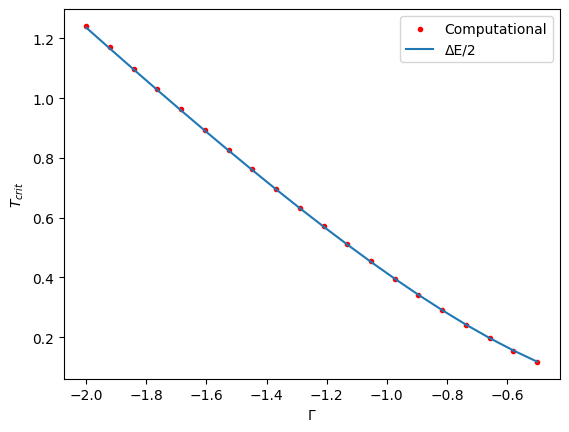

In [159]:
plt.scatter (G, T_crit_history, label="Computational", marker=".", color="red")
plt.plot (G, T_crit_approx, label="ΔE/2")
plt.xlabel(r"$\Gamma$")
plt.ylabel(r"$T_{crit}$") 
plt.legend()
plt.show()

In [19]:
state_vector = vstate.to_array()
# print("Vector de estado completo:")
# print(state_vector)

# Obtener estados individuales con sus amplitudes
basis_states = hi_extended.all_states()
for i, state in enumerate(basis_states):
    amplitude = state_vector[i]
#     print(f"Estado {state}: {amplitude:.3f}")

# Calcular probabilidades
probabilities = jnp.abs(state_vector)**2
for i, state in enumerate(basis_states):
    print(f"P(|{state}⟩) = {probabilities[i]:.3f}")

prob00= sum(probabilities[i] for i, state in enumerate(basis_states) if state[0]==-1 and state[1]==-1)
print(f"\nP(|-1-1⟩): {prob00:.3f}")
prob11= sum(probabilities[i] for i, state in enumerate(basis_states) if state[0]==1 and state[1]==1)
print(f"\nP(|11⟩): {prob11:.3f}")
p01= sum(probabilities[i] for i, state in enumerate(basis_states) if (state[0]==-1 and state[1]==1))
print(f"\nP(|-11⟩): {p01:.3f}")
p10= sum(probabilities[i] for i, state in enumerate(basis_states) if (state[0]==1 and state[1]==-1))
print(f"\nP(|1-1⟩): {p10:.3f}")

P(|[1 1 1 1]⟩) = 0.000
P(|[ 1  1  1 -1]⟩) = 0.000
P(|[ 1  1 -1  1]⟩) = 0.000
P(|[ 1  1 -1 -1]⟩) = 0.250
P(|[ 1 -1  1  1]⟩) = 0.000
P(|[ 1 -1  1 -1]⟩) = 0.250
P(|[ 1 -1 -1  1]⟩) = 0.000
P(|[ 1 -1 -1 -1]⟩) = 0.000
P(|[-1  1  1  1]⟩) = 0.000
P(|[-1  1  1 -1]⟩) = 0.000
P(|[-1  1 -1  1]⟩) = 0.250
P(|[-1  1 -1 -1]⟩) = 0.000
P(|[-1 -1  1  1]⟩) = 0.250
P(|[-1 -1  1 -1]⟩) = 0.000
P(|[-1 -1 -1  1]⟩) = 0.000
P(|[-1 -1 -1 -1]⟩) = 0.000

P(|-1-1⟩): 0.250

P(|11⟩): 0.250

P(|-11⟩): 0.250

P(|1-1⟩): 0.250
